In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('../Data/mmda2/smaller2.csv')
print(df.head())
print(df.info())

# Статистика по числовым столбцам
print(df.describe())

                        Track      Artist             Album  Year Duration  \
0                    Fly Away  38 Special        38 Special  1977     5:13   
1                Just Hang On  38 Special        38 Special  1977     5:01   
2              Long Time Gone  38 Special        38 Special  1977     4:01   
3          Who's Been Messin'  38 Special  Special Delivery  1978     4:16   
4  Can't Keep A Good Man Down  38 Special  Special Delivery  1978     3:19   

   Time_Signature  Danceability  Energy  Key  Loudness  Mode  Speechiness  \
0               4         0.563   0.563    2   -10.781     1       0.0263   
1               3         0.545   0.522    9    -9.971     1       0.0268   
2               4         0.599   0.816    0    -9.121     1       0.0288   
3               4         0.447   0.705    7   -11.884     1       0.0289   
4               4         0.567   0.784    0   -11.392     1       0.0302   

   Acousticness  Instrumentalness  Liveness  Valence    Tempo  Popul

In [3]:
from sklearn.preprocessing import TargetEncoder
enc_auto = TargetEncoder(smooth = "auto")
# X = df['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness']]
X = df.drop(columns = 'Artist')
y = df['Artist']  # Целевая переменная
X_trans = enc_auto.fit_transform(X, y)
print(X_trans)
X_train, X_test, y_train, y_test = train_test_split(X_trans, y, test_size = 0.2, stratify = y, random_state = 42)
print(X_train)
print(y_train)

[[0.02894212 0.03093812 0.04191617 ... 0.         0.         0.        ]
 [0.02894212 0.02994012 0.04291417 ... 0.         0.         0.        ]
 [0.02894212 0.03093812 0.04191617 ... 0.06465528 0.         0.        ]
 ...
 [0.02797203 0.03096903 0.04195804 ... 0.         0.         0.        ]
 [0.02894212 0.02994012 0.04291417 ... 0.         0.         0.07062476]
 [0.02797203 0.03096903 0.04195804 ... 0.10720478 0.         0.0779578 ]]
[[0.02797203 0.03096903 0.04195804 ... 0.         0.         0.        ]
 [0.02897103 0.02997003 0.04195804 ... 0.         0.         0.        ]
 [0.02894212 0.02994012 0.04291417 ... 0.         0.         0.        ]
 ...
 [0.02897103 0.02997003 0.04195804 ... 0.         0.         0.        ]
 [0.02797203 0.03096903 0.04195804 ... 0.         0.         0.0362557 ]
 [0.02894212 0.02994012 0.04291417 ... 0.         0.         0.04952269]]
889       Bob Seger
505        Bee Gees
798       Bob Dylan
669         Blondie
1010    Cheap Trick
           .

In [4]:
from sklearn import svm
from sklearn.linear_model import LogisticRegression

def check_acc(X_train, y_train, X_test, y_test):
    qda = QuadraticDiscriminantAnalysis()
    qda.fit(X_train, y_train)

    y_pred = qda.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Точность модели [qda]: {accuracy}")


    supp = svm.SVC(kernel='linear')
    supp.fit(X_train, y_train)

    y_pred_2 = supp.predict(X_test)
    accuracy_2 = accuracy_score(y_test, y_pred_2)

    print(f"Точность модели [svc]: {accuracy_2}")


    clf = LogisticRegression()
    clf.fit(X_train, y_train)
    y_pred3 = clf.predict(X_test)
    accuracy_3 = accuracy_score(y_test, y_pred3)
    print(f"Точность модели [lr]: {accuracy_3}")

In [5]:
check_acc(X_train, y_train, X_test, y_test)

/usr/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Точность модели [qda]: 0.07569721115537849
Точность модели [svc]: 0.9760956175298805
Точность модели [lr]: 0.9760956175298805


In [6]:
X_trans = pd.get_dummies(df.drop(columns=['Artist', 'Track', 'Duration']), columns=['Album'])
y = df[['Artist']]

print(X_trans)
print(X_trans.dtypes)

      Year  Time_Signature  Danceability  Energy  Key  Loudness  Mode  \
0     1977               4         0.563   0.563    2   -10.781     1   
1     1977               3         0.545   0.522    9    -9.971     1   
2     1977               4         0.599   0.816    0    -9.121     1   
3     1978               4         0.447   0.705    7   -11.884     1   
4     1978               4         0.567   0.784    0   -11.392     1   
...    ...             ...           ...     ...  ...       ...   ...   
1247  1973               4         0.514   0.882    5    -9.891     1   
1248  1974               4         0.373   0.279    5   -16.957     1   
1249  1974               4         0.295   0.476    0   -15.341     1   
1250  1974               4         0.468   0.637    2   -13.742     0   
1251  1974               4         0.368   0.734    9   -12.621     0   

      Speechiness  Acousticness  Instrumentalness  ...  \
0          0.0263      0.035700          0.001850  ...   
1      

In [7]:
from sklearn.preprocessing import OneHotEncoder
# one = OneHotEncoder()
# X = df.drop(columns = 'Artist')
# y = df['Artist']
# print(X)
print(y)
# X_trans = one.fit_transform(X_trans).toarray()
# print(X_trans)
X_train, X_test, y_train, y_test = train_test_split(X_trans, y, test_size = 0.2, random_state = 42)
# print(X_train)
# print(y_train)
# print(X_test)
# print(y_test)

           Artist
0      38 Special
1      38 Special
2      38 Special
3      38 Special
4      38 Special
...           ...
1247  David Bowie
1248  David Bowie
1249  David Bowie
1250  David Bowie
1251  David Bowie

[1252 rows x 1 columns]


In [8]:
check_acc(X_train, y_train, X_test, y_test)

/usr/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Точность модели [qda]: 0.9442231075697212


/usr/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Точность модели [svc]: 0.8087649402390438


/usr/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Точность модели [lr]: 0.19123505976095617


/usr/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.preprocessing import LabelEncoder

df_trans = pd.DataFrame()
label = LabelEncoder()
for c in df.columns:
    if(df[c].dtype == 'object'):
        df_trans[c] = label.fit_transform(df[c])
    else:
        df_trans[c] = df[c]

X = df_trans.copy()
y = X.pop('Artist')

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int
print(X)
print(y)
check_acc(X, )

      Track  Album  Year  Duration  Time_Signature  Danceability  Energy  Key  \
0       309      4  1977       217               4         0.563   0.563    2   
1       526      4  1977       205               3         0.545   0.522    9   
2       594      4  1977       145               4         0.599   0.816    0   
3      1172    261  1978       160               4         0.447   0.705    7   
4       137    261  1978       104               4         0.567   0.784    0   
...     ...    ...   ...       ...             ...           ...     ...  ...   
1247    819    223  1973        48               4         0.514   0.882    5   
1248   1127     98  1974       205               4         0.373   0.279    5   
1249    961     98  1974        57               4         0.295   0.476    0   
1250     12     98  1974       112               4         0.468   0.637    2   
1251    139     98  1974        65               4         0.368   0.734    9   

      Loudness  Mode  Speec

Album               5.109316
Track               1.087827
Year                1.006039
Acousticness        0.250832
Energy              0.215196
Popularity          0.211679
Loudness            0.201889
Danceability        0.127017
Duration            0.125928
Valence             0.103263
Instrumentalness    0.100233
Speechiness         0.076570
Key                 0.073772
Liveness            0.065438
Tempo               0.063922
Mode                0.022500
Time_Signature      0.000000
Name: MI Scores, dtype: float64


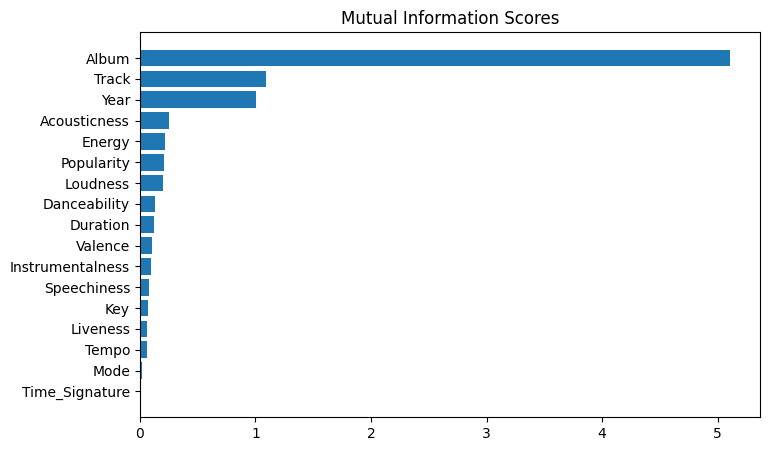

In [10]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features = discrete_features)
    mi_scores = pd.Series(mi_scores, name = "MI Scores", index = X.columns)
    mi_scores = mi_scores.sort_values(ascending = False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
print(mi_scores)

def plot_mi_scores(scores):
    scores = scores.sort_values(ascending = True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi = 100, figsize = (8, 5))
plot_mi_scores(mi_scores)

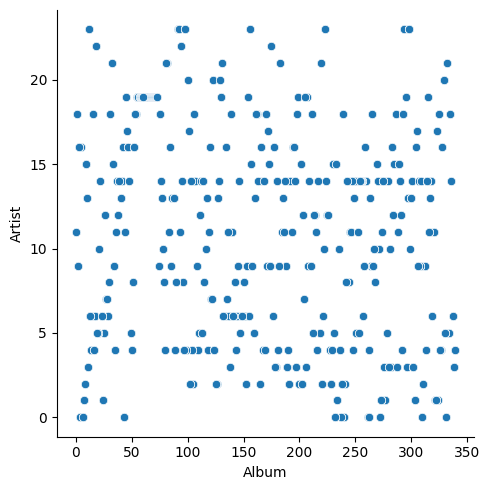

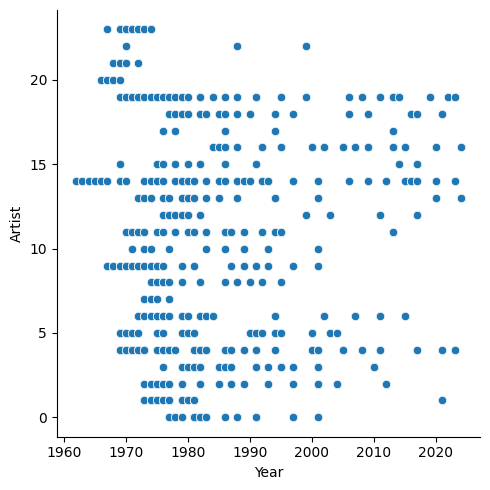

In [11]:
import seaborn as sns

sns.relplot(x = "Album", y = "Artist", data = df_trans)
sns.relplot(x = "Year", y = "Artist", data = df_trans)

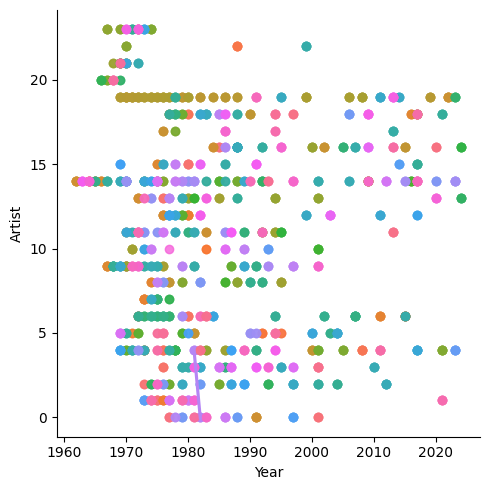

In [12]:
sns.lmplot(x = 'Year', y = 'Artist', hue = 'Album', legend = False, data = df_trans)

In [13]:
X = df_trans[[x for (x, y) in mi_scores.items() if y > 0.2]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
print(X)

      Album  Track  Year  Acousticness  Energy  Popularity  Loudness
0         4    309  1977      0.035700   0.563          13   -10.781
1         4    526  1977      0.248000   0.522           9    -9.971
2         4    594  1977      0.003040   0.816          26    -9.121
3       261   1172  1978      0.003600   0.705           7   -11.884
4       261    137  1978      0.061000   0.784           7   -11.392
...     ...    ...   ...           ...     ...         ...       ...
1247    223    819  1973      0.000671   0.882          28    -9.891
1248     98   1127  1974      0.760000   0.279          35   -16.957
1249     98    961  1974      0.643000   0.476          34   -15.341
1250     98     12  1974      0.624000   0.637          37   -13.742
1251     98    139  1974      0.803000   0.734          35   -12.621

[1252 rows x 7 columns]


In [14]:
check_acc(X_train, y_train, X_test, y_test)

Точность модели [qda]: 0.30677290836653387
Точность модели [svc]: 0.2868525896414343
Точность модели [lr]: 0.1553784860557769


/usr/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
X = df_trans.copy()[['Album', 'Year', 'Duration', 'Artist']]
y = X.pop('Artist')
X = X.loc[:]

# Standardize
X_scaled = (X - X.mean(axis = 0)) / X.std(axis = 0)
print(X_scaled)

         Album      Year  Duration
0    -1.685513 -0.630278  1.093359
1    -1.685513 -0.630278  0.906455
2    -1.685513 -0.630278 -0.028065
3     0.930014 -0.566357  0.205565
4     0.930014 -0.566357 -0.666655
...        ...       ...       ...
1247  0.543282 -0.885963 -1.538874
1248 -0.728861 -0.822042  0.906455
1249 -0.728861 -0.822042 -1.398696
1250 -0.728861 -0.822042 -0.542052
1251 -0.728861 -0.822042 -1.274093

[1252 rows x 3 columns]


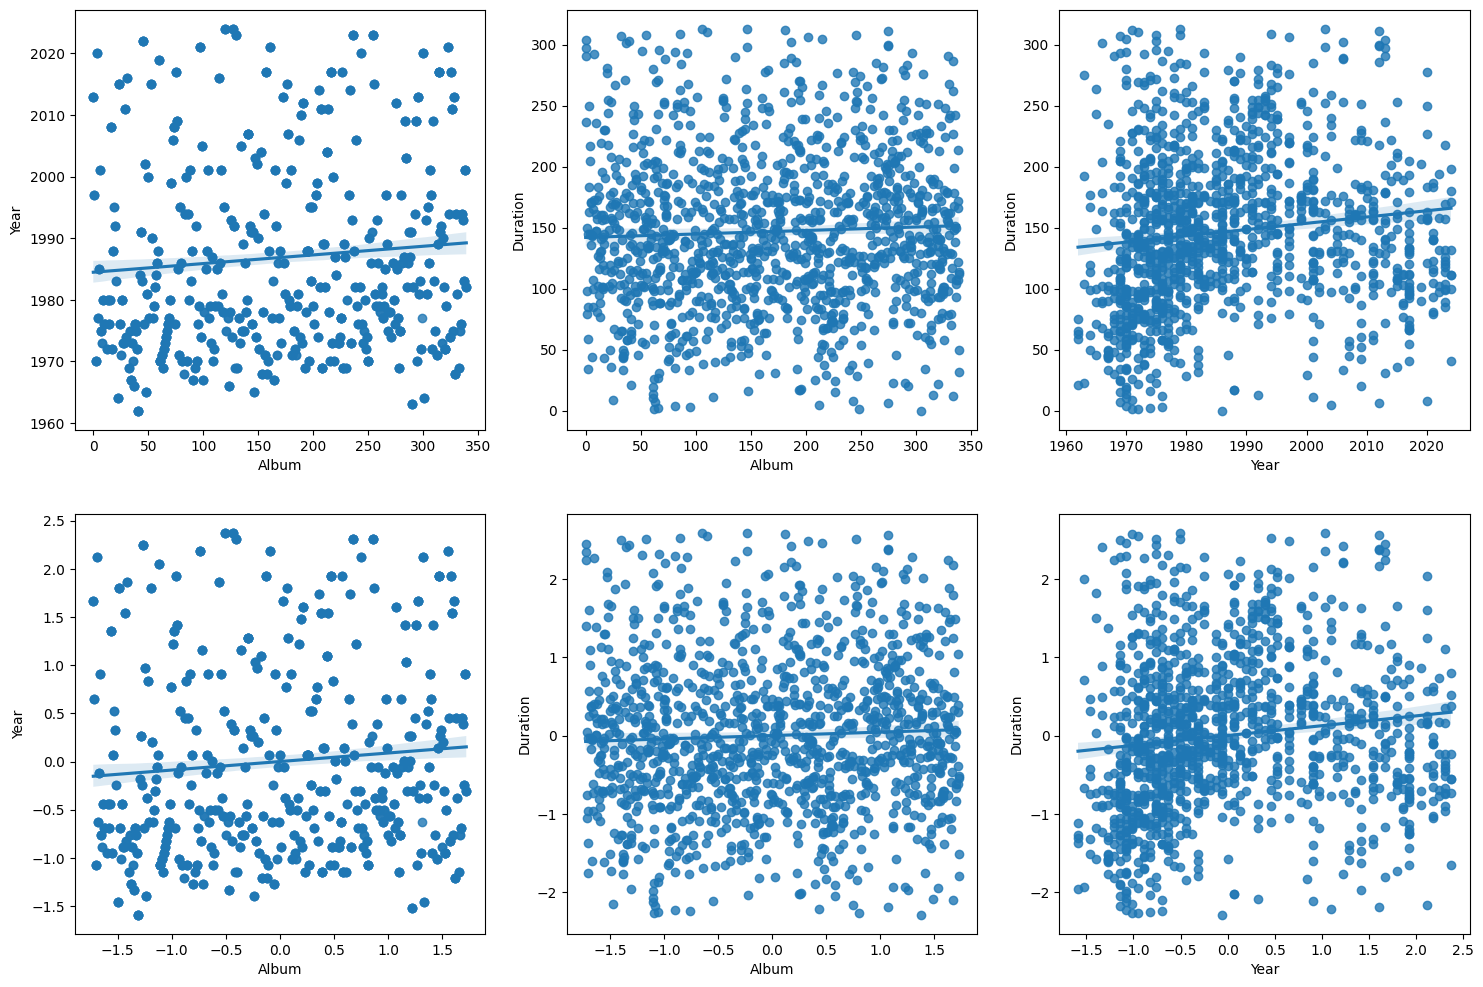

In [16]:
import itertools

def plot_spec(feats, X = None, X_diff = None):
    j = 2
    if X is None or X_diff is None:
        j = 1
    fig, axes = plt.subplots(j, 3, figsize = (18, 6 * j))
    for i, (feat1, feat2) in enumerate(itertools.combinations(range(3), 2)):
        if (X is not None and j == 2):
            sns.regplot(ax = axes[0, i % 3], data = X, x = feats[feat1], y = feats[feat2])
        elif (X is not None and j == 1):
            sns.regplot(ax = axes[i % 3], data = X, x = feats[feat1], y = feats[feat2])
        if (X_diff is not None and j == 2):
            sns.regplot(ax = axes[1, i % 3], data = X_diff, x = feats[feat1], y = feats[feat2])
        elif (X_diff is not None and j == 1):
            sns.regplot(ax = axes[i % 3], data = X_diff, x = feats[feat1], y = feats[feat2])

feats = ['Album', 'Year', 'Duration']
plot_spec(X = X, X_diff = X_scaled, feats = feats)

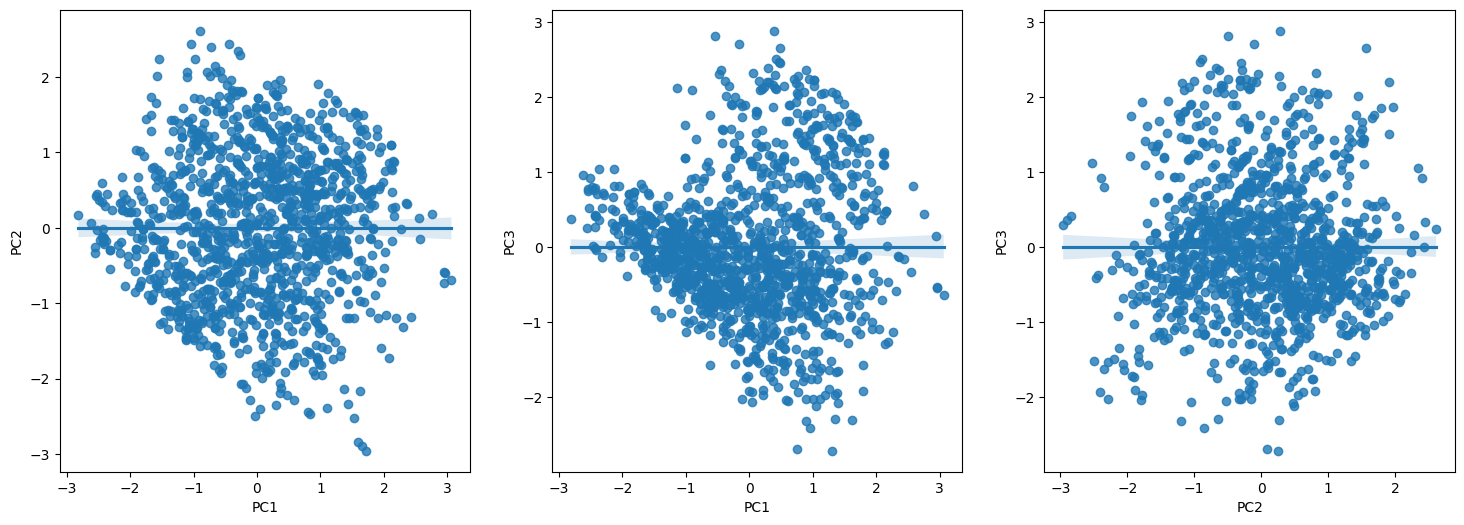

In [17]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Convert to dataframe
component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns = component_names)

X_pca.head()

plot_spec(X_diff = X_pca, feats = component_names)

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,  # transpose the matrix of loadings
    columns = component_names,  # so the columns are the principal components
    index = X.columns,  # and the rows are the original features
)
print(loadings)

               PC1       PC2       PC3
Album     0.474940  0.829364 -0.294256
Year      0.656432 -0.111178  0.746147
Duration  0.586113 -0.547534 -0.597225


In [19]:
# plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout = True)
plt.rc(
    "axes",
    labelweight = "bold",
    labelsize = "large",
    titleweight = "bold",
    titlesize = 14,
    titlepad = 10,
)

def plot_variance(pca):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel = "Component", title = "% Explained Variance", ylim = (0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel = "Component", title = "% Cumulative Variance", ylim = (0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth = 8, dpi = 100)
    return axs

PC1    0.115158
PC3    0.112423
PC2    0.090860
Name: MI Scores, dtype: float64


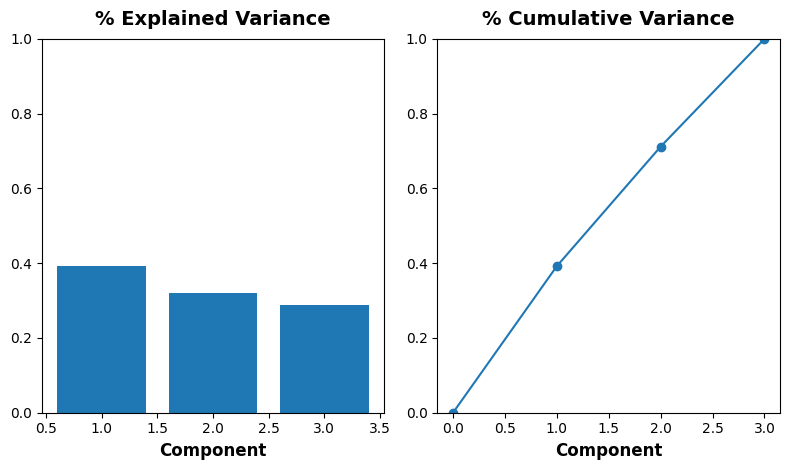

In [20]:
plot_variance(pca)

mi_scores = make_mi_scores(X_pca, y, discrete_features = False)
print(mi_scores)

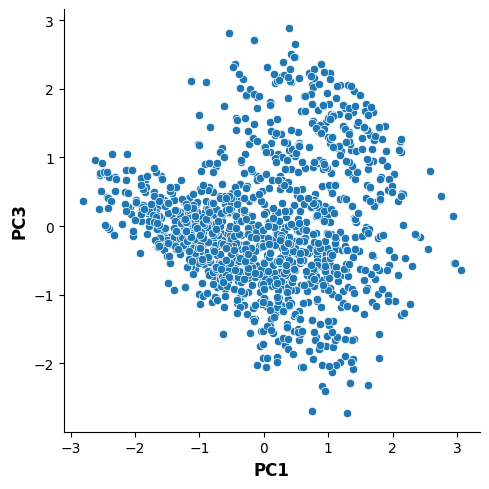

In [21]:
sns.relplot(data = X_pca, x = 'PC1', y = 'PC3')

In [66]:
from numpy.linalg import eig

X = df_trans.copy()[['Album', 'Year', 'Duration', 'Artist']]
y = X.pop('Artist')
X = X.loc[:]

X_scaled = (X - X.mean(axis = 0)) / X.std(axis = 0)

# print(X_scaled)
# print(X_scaled.shape)
_, n_features = X_scaled.shape
print(n_features)
cov = np.cov(X_scaled.T)

eig_vals, eig_vecs = eig(cov)
print('Eigenvectors \n', eig_vecs)
max_abs_idx = np.argmax(np.abs(eig_vecs), axis = 0)
print(np.abs(eig_vecs))
print(max_abs_idx)
signs = np.sign(eig_vecs[max_abs_idx, range(eig_vecs.shape[0])])
print(signs)
eig_vecs = eig_vecs * signs[np.newaxis, :]
print(eig_vecs)
eig_vecs = eig_vecs.T

print('Eigenvalues \n', eig_vals)
print('Eigenvectors \n', eig_vecs)

3
Eigenvectors 
 [[-0.47493986 -0.82936449  0.29425613]
 [-0.65643233  0.11117841 -0.74614741]
 [-0.58611324  0.54753438  0.59722472]]
[[0.47493986 0.82936449 0.29425613]
 [0.65643233 0.11117841 0.74614741]
 [0.58611324 0.54753438 0.59722472]]
[1 0 1]
[-1. -1. -1.]
[[ 0.47493986  0.82936449 -0.29425613]
 [ 0.65643233 -0.11117841  0.74614741]
 [ 0.58611324 -0.54753438 -0.59722472]]
Eigenvalues 
 [1.17599361 0.95931901 0.86468738]
Eigenvectors 
 [[ 0.47493986  0.65643233  0.58611324]
 [ 0.82936449 -0.11117841 -0.54753438]
 [-0.29425613  0.74614741 -0.59722472]]


In [70]:
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[i, :]) for i in range(len(eig_vals))]

eig_pairs.sort(key = lambda x: x[0], reverse = True)

eig_vals_sorted = np.array([x[0] for x in eig_pairs])
eig_vecs_sorted = np.array([x[1] for x in eig_pairs])

print(eig_pairs)
k = n_features
Wg = eig_vecs_sorted[:k, :]
print(Wg)

print(Wg.shape)

[(np.float64(1.17599360747093), array([0.47493986, 0.65643233, 0.58611324])), (np.float64(0.9593190107537191), array([ 0.82936449, -0.11117841, -0.54753438])), (np.float64(0.8646873817753478), array([-0.29425613,  0.74614741, -0.59722472]))]
[[ 0.47493986  0.65643233  0.58611324]
 [ 0.82936449 -0.11117841 -0.54753438]
 [-0.29425613  0.74614741 -0.59722472]]
(3, 3)


Explained variance: [39.2  31.98 28.82]
Cumulative explained variance: [ 39.2   71.18 100.  ]


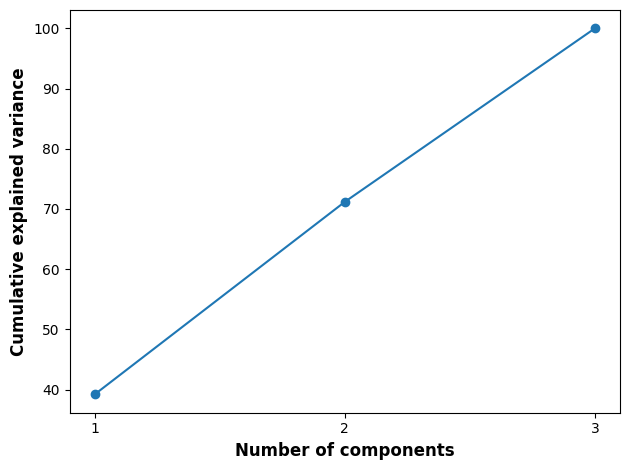

In [71]:
eig_vals_total = sum(eig_vals)
explained_variance = [(i / eig_vals_total) * 100 for i in eig_vals_sorted]
explained_variance = np.round(explained_variance, 2)
cum_explained_variance = np.cumsum(explained_variance)

print('Explained variance: {}'.format(explained_variance))
print('Cumulative explained variance: {}'.format(cum_explained_variance))

plt.plot(np.arange(1, n_features + 1), cum_explained_variance, '-o')
plt.xticks(np.arange(1, n_features + 1))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

             0         1         2
0    -0.573420 -1.926483 -0.627289
1    -0.682967 -1.824146 -0.515665
2    -1.230702 -1.312464  0.042453
3     0.190410  0.721733 -0.819016
4    -0.320809  1.199303 -0.298105
...        ...       ...       ...
1247 -1.225503  1.391665  0.098130
1248 -0.354495 -1.009413 -0.940250
1249 -1.705574  0.252736  0.436443
1250 -1.203484 -0.216306 -0.075166
1251 -1.632543  0.184512  0.362027

[1252 rows x 3 columns]
(1252, 3)
RangeIndex(start=0, stop=3, step=1)


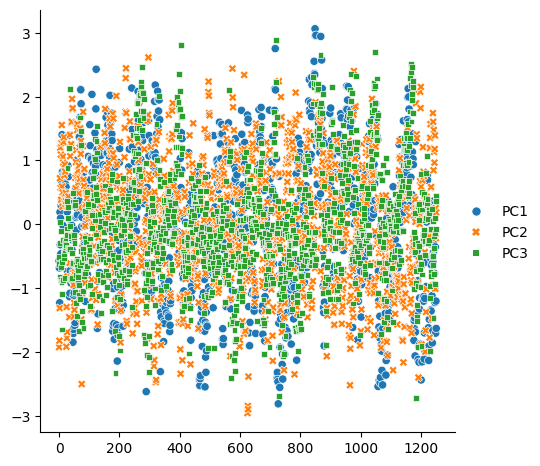

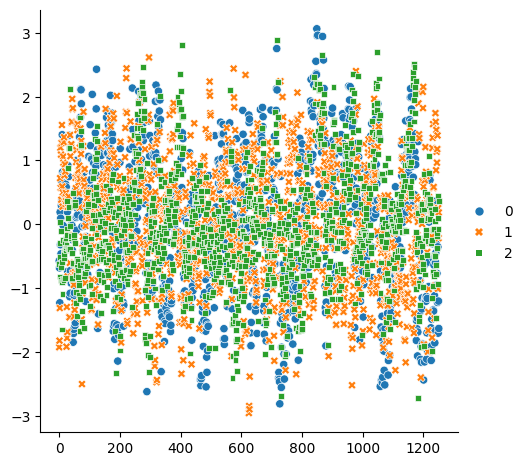

In [72]:
X_proj = X_scaled.dot(Wg.T)
print(X_proj)
print(X_proj.shape)

sns.relplot(data = X_pca)
print(X_proj.columns)
sns.relplot(data = X_proj)
# sns.relplot(data = X_pca, x = 'PC1', y = 'PC3')
# sns.relplot(data = X_proj, x = X_proj.loc[0], y = X_proj.loc[2])